In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

%matplotlib inline

# Load data
df = pd.read_csv("train.csv")

print("Initial shape:", df.shape)

Initial shape: (913000, 4)


In [2]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek

In [3]:
df = df.sort_values(by=['store', 'item', 'date'])

df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)

df = df.dropna(subset=['lag_1', 'lag_7', 'lag_30'])

print("After lag:", df.shape)

After lag: (898000, 11)


In [4]:
df_sample = df.sample(n=200000, random_state=42)

In [5]:
features = [
    'store', 'item',
    'day', 'month', 'year', 'day_of_week',
    'lag_1', 'lag_7', 'lag_30'
]

X = df_sample[features]
y = df_sample['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
model = HistGradientBoostingRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 6.483999526289354


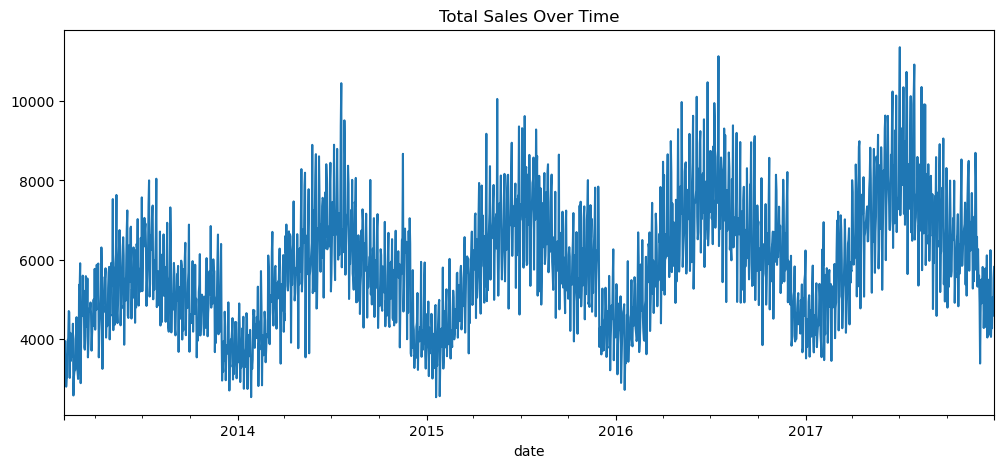

In [7]:
plt.figure(figsize=(12,5))
df_sample.groupby('date')['sales'].sum().plot()
plt.title("Total Sales Over Time")
plt.show()

In [8]:
# Demand variability per item
demand_std = df.groupby('item')['sales'].std()

df = df.merge(demand_std.rename('demand_std'), on='item')

# Safety stock (95% service level)
Z = 1.65
df['safety_stock'] = Z * df['demand_std']

In [9]:
high_variability = df.groupby('item')['demand_std'].mean().sort_values(ascending=False).head(10)

print("Top High Variability Items:")
print(high_variability)

Top High Variability Items:
item
15    29.288342
28    29.276766
18    28.208569
13    28.089355
45    27.100113
25    27.022469
38    26.922789
22    26.904888
8     25.938285
36    25.860382
Name: demand_std, dtype: float64
